In [2]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.stats import linregress, lognorm
from datetime import datetime
from tabulate import tabulate
import os
from dbfread import DBF
import openpyxl
import ssl
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.utils import ImageReader
import geopandas as gpd

Pasta Chikungunya_Dourados_graficos criada!


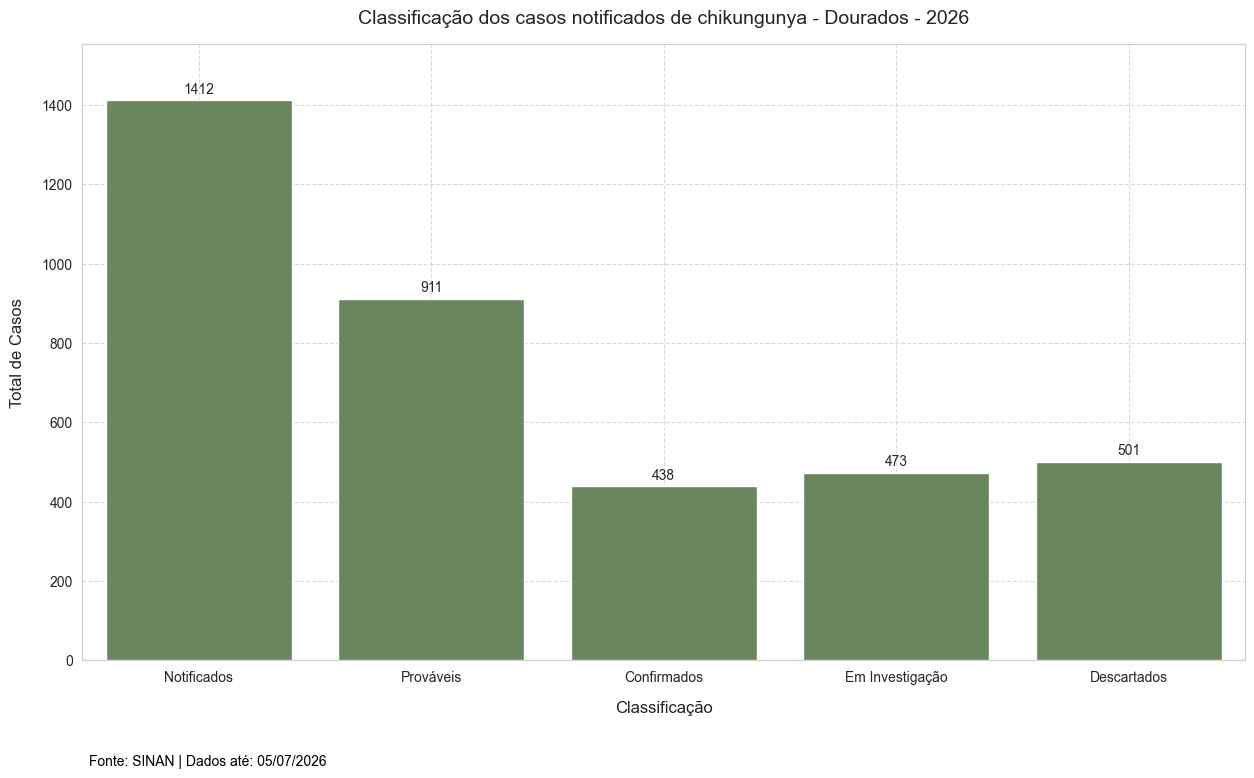

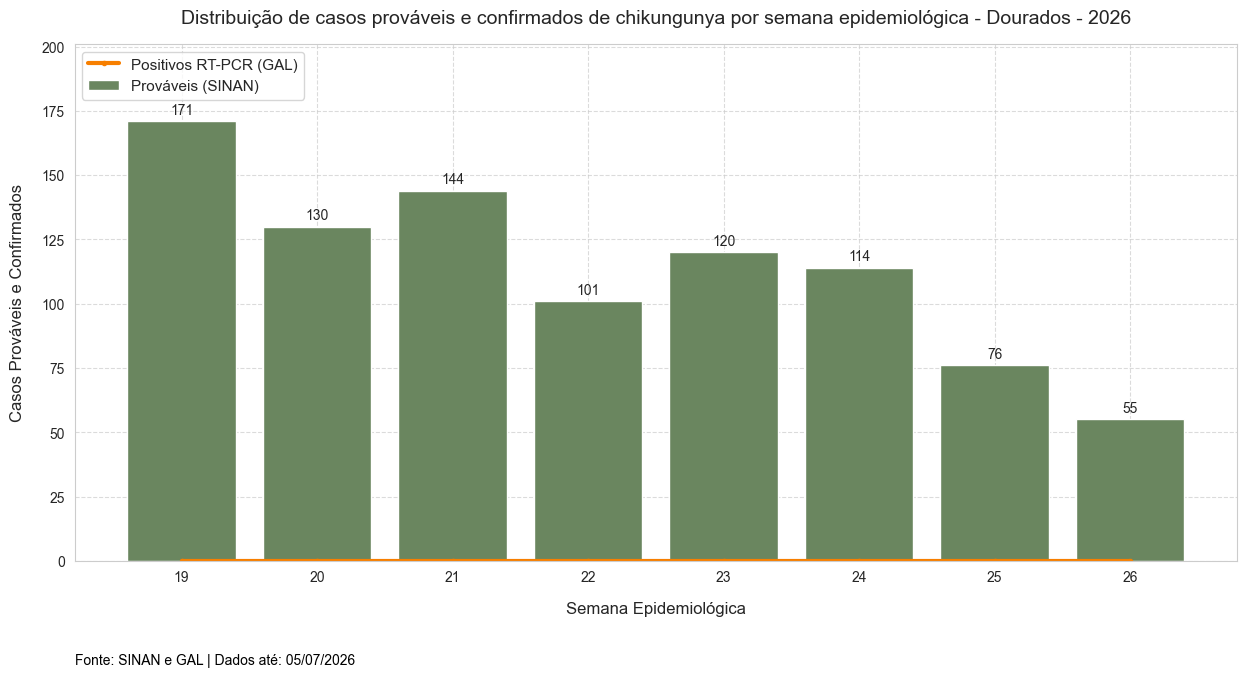

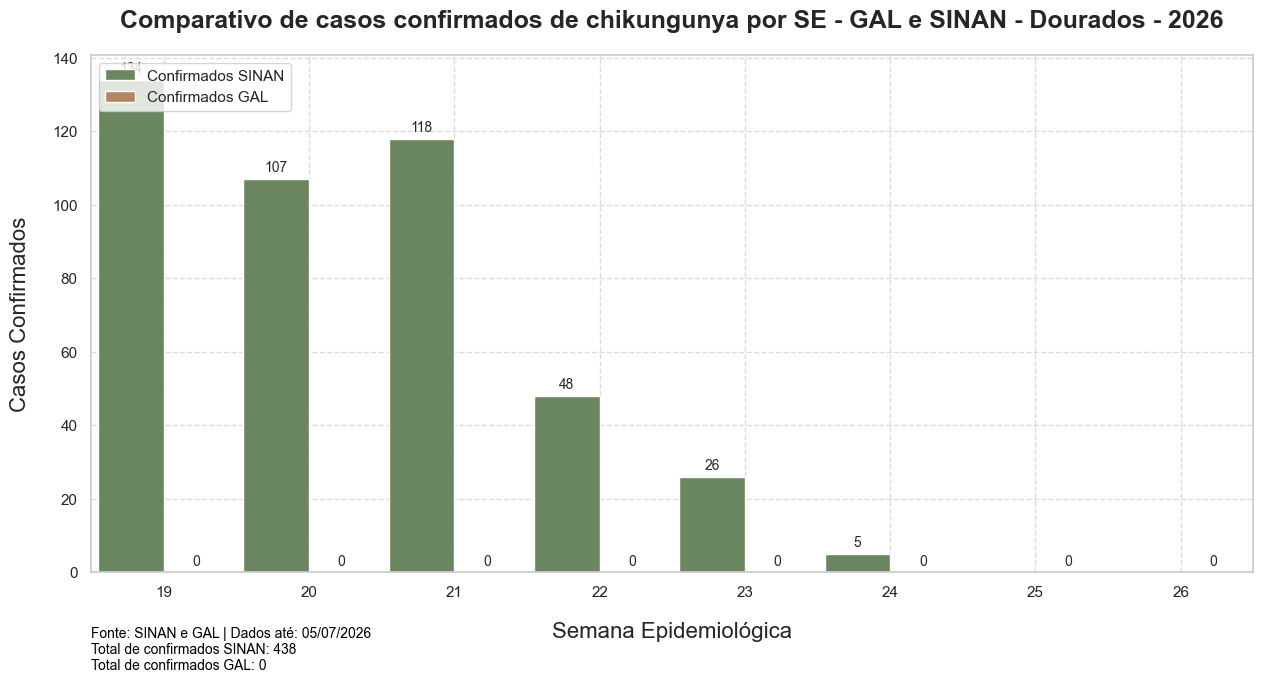

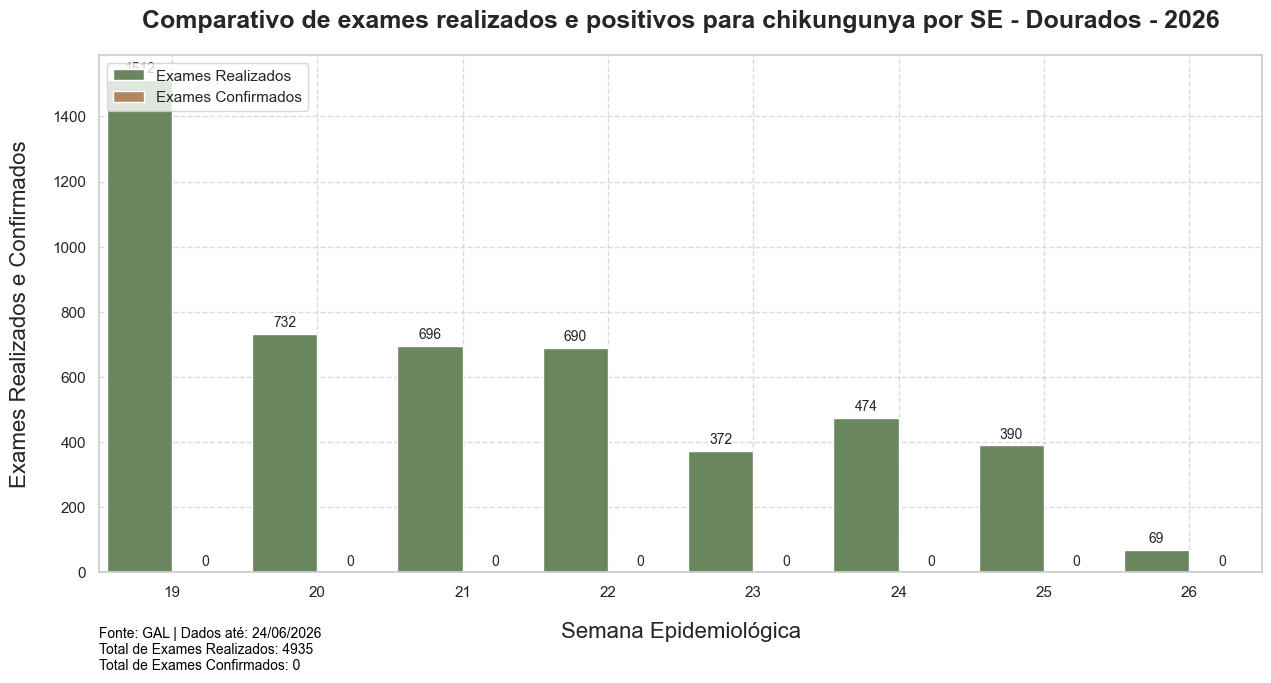

C:\Users\pedro.arthur\AppData\Local\Temp\ipykernel_23484\439644300.py:270: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(data=df_combinado, x='SE', y='Total', hue='Confirmados',


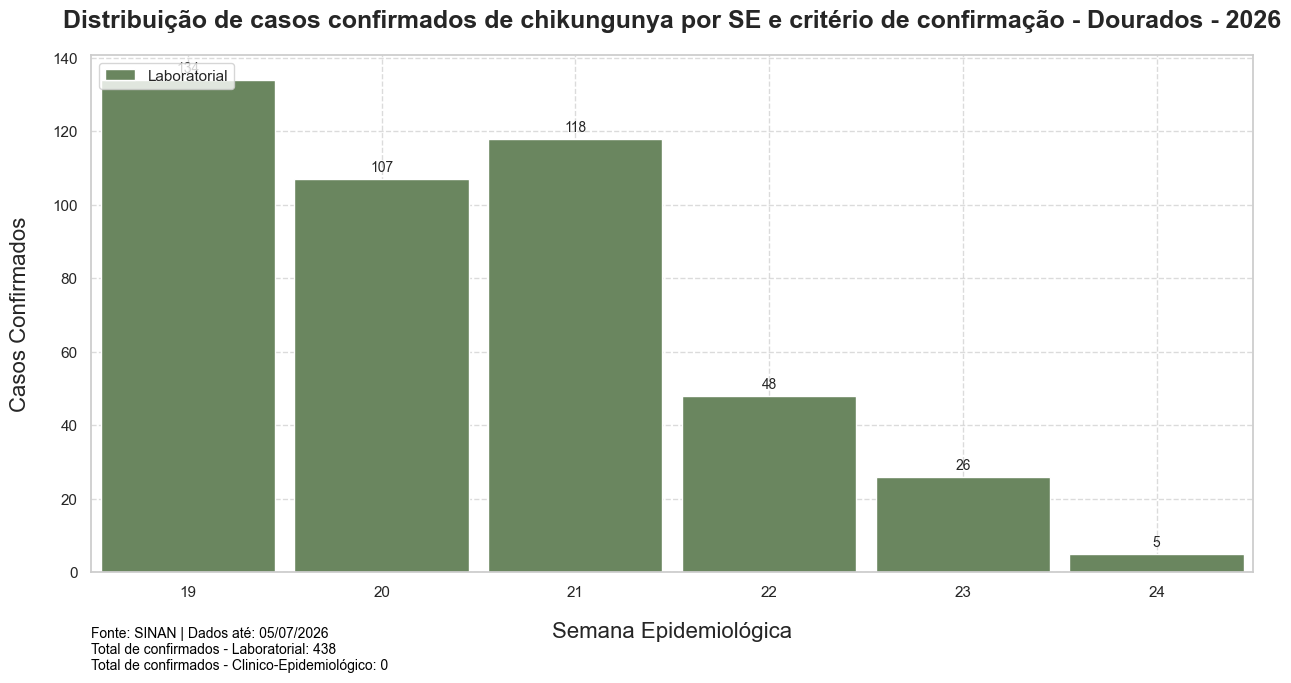

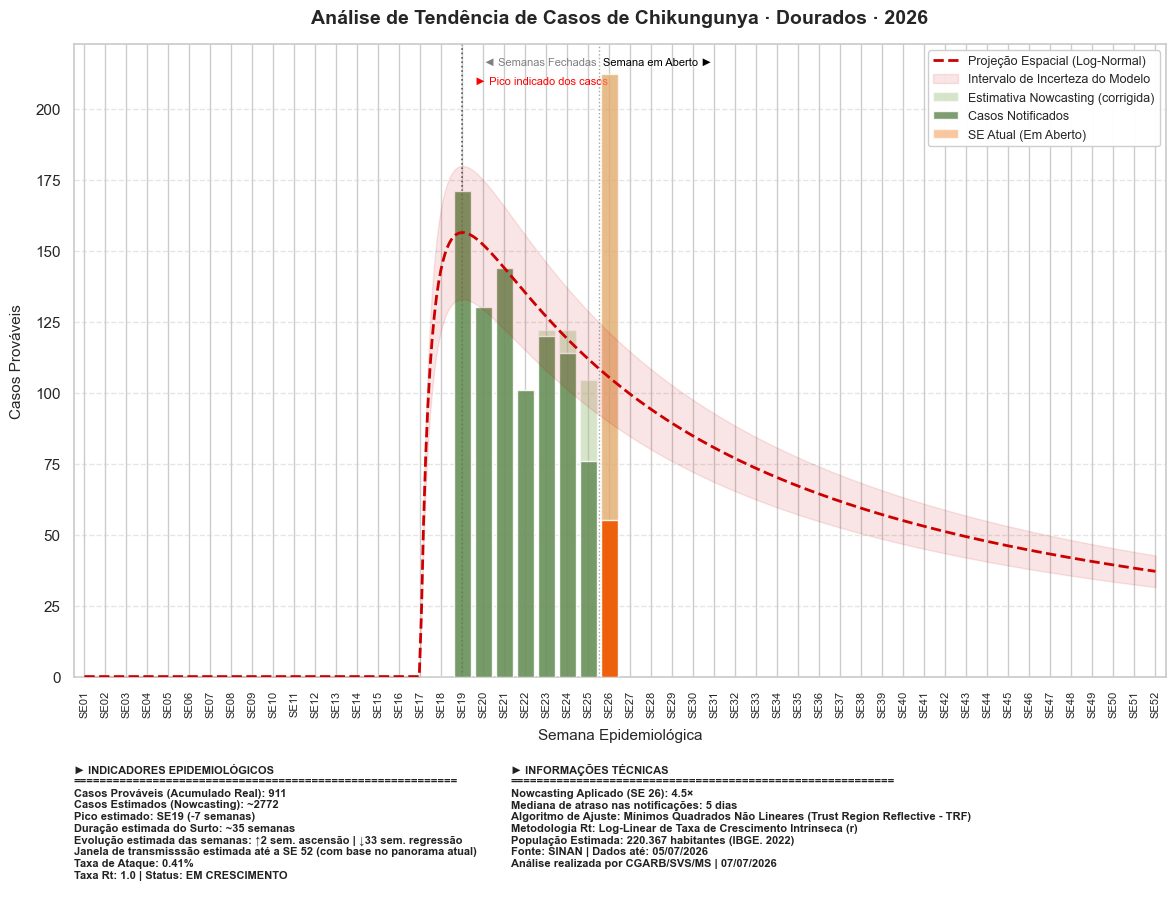

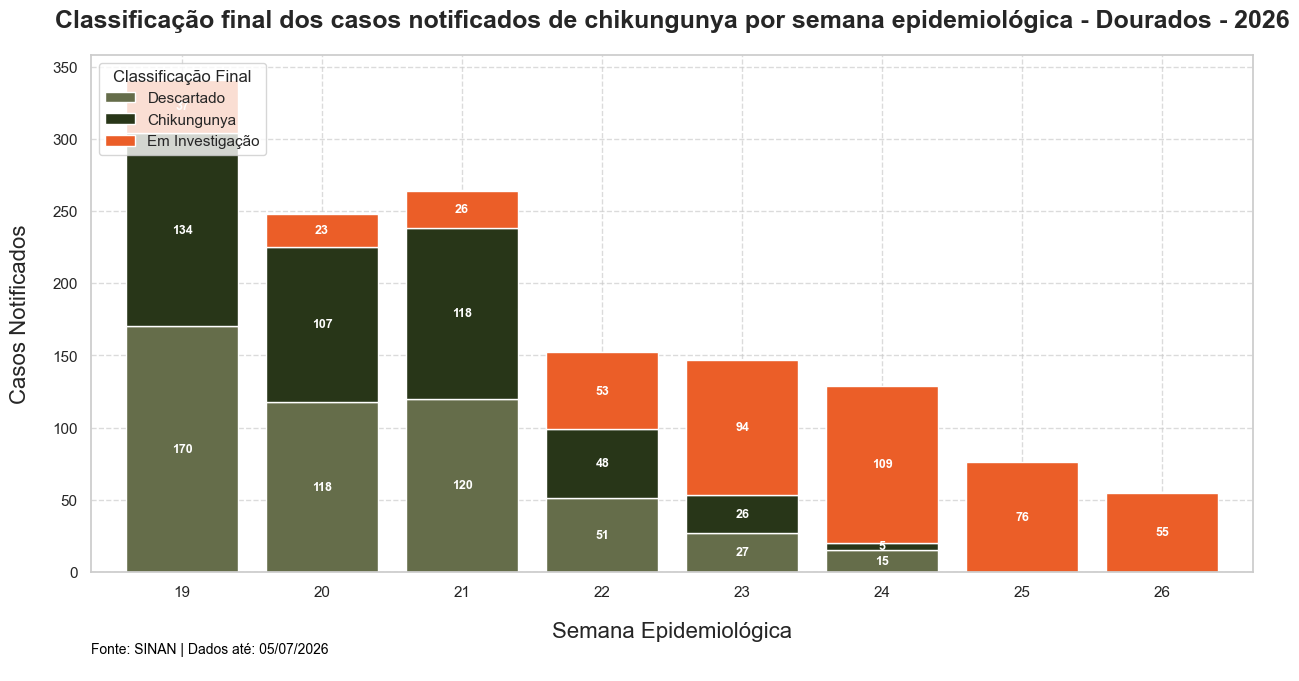

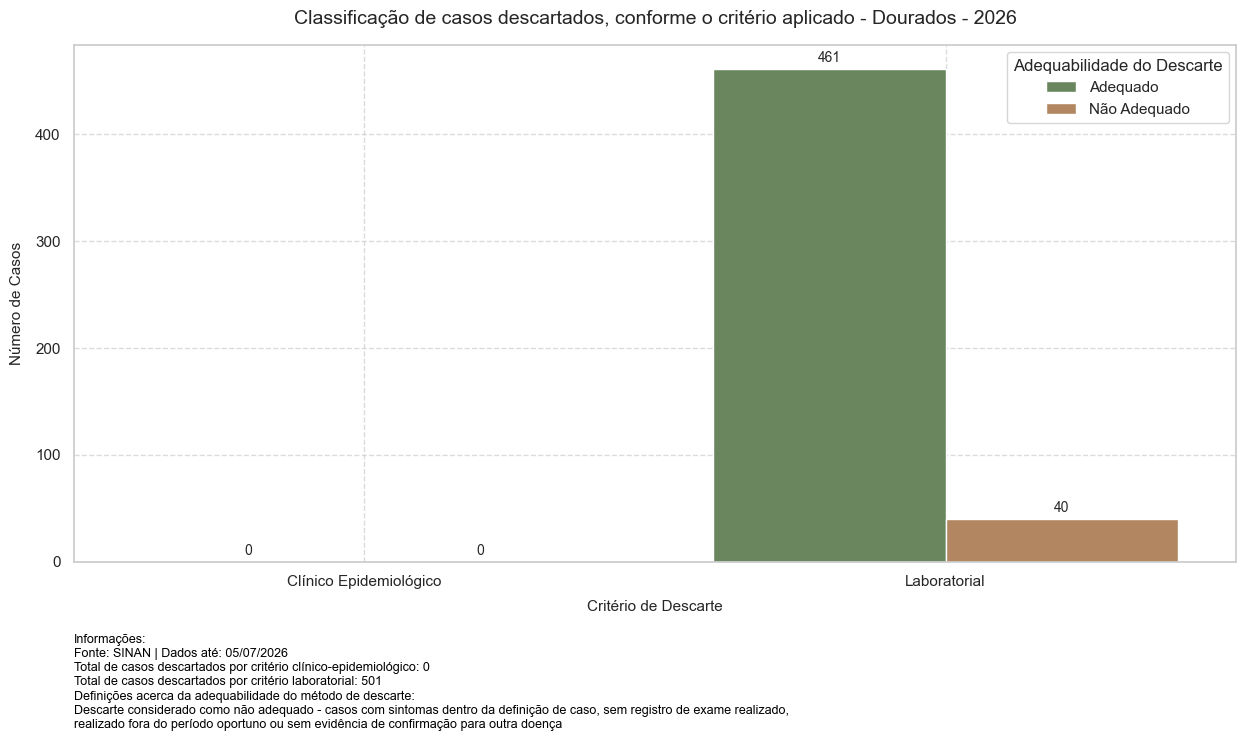

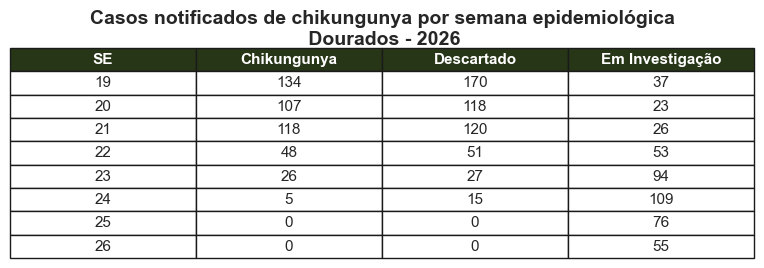

Planilha de análise gerada com sucesso!
Arquivo Relatorio_Chikungunya_Dourados_2026.pdf gerado com sucesso!
-----------------------------------
OUTPUT DE ANÁLISE - DOURADOS - (SE01 a SE26)
Mediana de atraso: 5 dias
Maior atraso registrado: 36 dias
Menor atraso registrado: 0 dias

Taxa de ataque: 0.4%

ANÁLISE DE TENDÊNCIA — CHIKUNGUNYA DOURADOS - (07/07/2026)
Fator Corretor Aplicado na Janela Aberta: 1.02x
Métricas Exponenciais: r = +0.0103 | Rt Real Calculado = 1.01
Casos Brutos Consolidados: 911 | Corrigidos pós-Nowcasting: 1106

PROJEÇÃO EPIDEMIOLÓGICA LOG-NORMAL
Pico Previsto: SE19 (-7 semanas)
Casos no pico: ~156 casos
Tempo estimado do surto: 35 semanas
Casos Totais Projetados: ~2772 casos acumulados
Janela de transmissão estimada até a SE52


In [3]:
# ===========================================
# Dicionário de Variáveis para filtro
nome_municipio = 'Dourados'    # NÃO USAR ACENTO
mun_sinan = 500370
mun_gal = nome_municipio.upper()
populacao = 220_367
data_dados = '05/07/2026'

# ===========================================

# Criar pasta para salvar os arquivos
nome_pasta = f'Chikungunya_{nome_municipio}_graficos'
local_salvar = os.getcwd()
local_pasta = os.path.join(local_salvar, nome_pasta)

if not os.path.exists(local_pasta):
    os.makedirs(local_pasta)
    print(f"Pasta {nome_pasta} criada!")
else:
    print(f"A pasta {nome_pasta} já existe. Os arquivos serão salvos nela.")

# ===========================================

# Processamento da base de dados (CHIKON SINAN)

# Carregamento das bases de dados
df_provaveis = pd.read_excel('chik_brasil_provaveis_2026.xlsx')
df_notificados = pd.read_excel('chik_brasil_notificados_2026.xlsx')
df_gal_final = pd.read_excel('chik_brasil_gal_2026.xlsx')
df_municipios = pd.read_excel('municipios_brasil.xlsx')

# Filtragem das bases de dados para o município desejado
df_provaveis_filtrado = df_provaveis[df_provaveis['ID_MN_RESI'] == mun_sinan]
df_notificados_filtrado = df_notificados[df_notificados['ID_MN_RESI'] == mun_sinan]
df_gal_final_filtrado = df_gal_final[df_gal_final['Municipio'] == mun_gal]

# ===========================================

# Variáveis de classificação
notificados = len(df_notificados_filtrado)
provaveis = len(df_provaveis_filtrado)
descartados = (df_notificados_filtrado['CLASSI_FIN'] == 5).sum()
confirmados = (df_notificados_filtrado['CLASSI_FIN'] == 13).sum()
investigacao = df_notificados_filtrado['CLASSI_FIN'].isna().sum()

# ===========================================

# DataFrame agrupado
df_class = pd.DataFrame({
    'Notificados': [notificados],
    'Prováveis': [provaveis],
    'Confirmados': [confirmados],
    'Em Investigação': [investigacao],
    'Descartados': [descartados]
})

# ===========================================

# Gráfico de prováveis de acordo com a classificação do caso
grafico_class = plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[4, 1])
ax = grafico_class.add_subplot()

sns.barplot(data=df_class, color='#678d58', ax=ax)
ax.bar_label(ax.containers[0], fmt='%d', padding=3, fontsize=10)
ax.set_title(f'Classificação dos casos notificados de chikungunya - {nome_municipio} - 2026', fontsize=14, pad=15)
ax.set_xlabel('Classificação', fontsize=12, labelpad=12)
ax.set_ylabel('Total de Casos', fontsize=12, labelpad=12)
ax.set_ylim(0, df_class.values.max() * 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Informações para o rodapé
ax_rodape = grafico_class.add_subplot(gs[1])
ax_rodape.axis('off')
rodape_texto = f"Fonte: SINAN | Dados até: {data_dados}"
ax_rodape.text(0.21, -0.9, rodape_texto, ha='right', va='center', fontsize=10, color='black')

salvar_pasta = os.path.join(local_pasta, f'chik_classificacao_{nome_municipio}.png')
plt.savefig(salvar_pasta, dpi = 300, bbox_inches = 'tight')
plt.show()

# ===========================================
# Gráfico de casos prováveis e casos confirmados por semana epidemiológica
# dataframe de casos prováveis por semanas para gráfico
df_semanas = df_provaveis_filtrado['SE'].value_counts().reset_index()
df_semanas.columns = ['SE', 'Total']
df_semanas = df_semanas.sort_values('SE').reset_index(drop=True)

df_gal_semana = df_gal_final_filtrado.groupby('SE')[['Casos_Positivos']].sum().reset_index()

# Junção dos dois dataframe
df_unico = pd.merge(df_semanas, df_gal_semana, on='SE', how='left').fillna(0)

# visualização dos dados por semana epidemiológica
grafico_semanas = plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_semanas.add_subplot(gs[0])

sns.barplot(x='SE', y='Total', data=df_unico, color='#678d58', ax=ax, label='Prováveis (SINAN)')
ax.bar_label(ax.containers[0], fmt='%d', padding=3, fontsize=10)
ax.plot(df_unico.index, df_unico['Casos_Positivos'], color="#f77f00", 
        linewidth=3, marker='o', markersize=3, label='Positivos RT-PCR (GAL)')

# Rótulos da Linha (Loop que passa por cada ponto e escreve o número em cima)
#for i, row in df_unico.iterrows():
    # Só coloca o rótulo se tiver mais de 0 casos para não poluir o gráfico
    #if row['Casos_Positivos'] > 0: 
        # O +80 abaixo empurra o texto um pouco para cima do ponto da linha para não sobrepor
        #ax.text(i, row['Casos_Positivos'] + 80, f"{int(row['Casos_Positivos'])}", 
                #ha='center', va='bottom', fontsize=10, color="#000000", fontweight='bold')

ax.set_title(f'Distribuição de casos prováveis e confirmados de chikungunya por semana epidemiológica - {nome_municipio} - 2026', fontsize=14, pad=15)
ax.set_xlabel('Semana Epidemiológica', fontsize=12, labelpad=12)
ax.set_ylabel('Casos Prováveis e Confirmados', fontsize=12, labelpad=12)
ax.set_ylim(0, df_semanas['Total'].max() + 30)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(fontsize = 11, loc = 'upper left', frameon = True)

# Informações para o rodapé
ax_rodape = grafico_semanas.add_subplot(gs[1])
ax_rodape.axis('off')
rodape_texto = f"Fonte: SINAN e GAL | Dados até: {data_dados}"
ax_rodape.text(0.0, 0.0, rodape_texto, ha='left', va='center', fontsize=10, color='black')

salvar_pasta = os.path.join(local_pasta, f'chik_provaveis_confirmados_se_{nome_municipio}.png')
plt.savefig(salvar_pasta, dpi = 300, bbox_inches = 'tight')
plt.show()

# ===========================================

# COMPARATIVO ENTRE CONFIRMADOS SINAN E CONFIRMADOS GAL
# Filtrar casos confirmados na base do SINAN
df_provaveis_filtrado['SE'] = pd.to_numeric(df_provaveis_filtrado['SE'], errors='coerce')
df_conf_semanas = df_provaveis_filtrado[df_provaveis_filtrado['CLASSI_FIN'] == 13].groupby('SE').size().reset_index(name='Total')

# Contar os casos positivos na base do GAL
df_gal_conf = df_gal_final_filtrado.groupby('SE')['Casos_Positivos'].sum().reset_index()
df_gal_conf.columns = ['SE', 'Total']

df_conf_semanas['Confirmados'] = 'Confirmados SINAN'
df_gal_conf['Confirmados'] = 'Confirmados GAL'

# Configurar o estilo visual
grafico_sem = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_sem.add_subplot(gs[0])

df_combinado = pd.concat([df_conf_semanas, df_gal_conf], ignore_index=True)

# Criar o Gráfico de Barras Verticais
sns.barplot(data=df_combinado, x='SE', y='Total', hue='Confirmados',
            palette= ['#678d58', '#c08552'], ax=ax, width= 0.9)

for c in ax.containers:
    ax.bar_label(c, fmt='%d', padding=3, fontsize=10)

# Estilização dos Eixos e Legenda
ax.set_title(f'Comparativo de casos confirmados de chikungunya por SE - GAL e SINAN - {nome_municipio} - 2026', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Semana Epidemiológica', fontsize=16, labelpad=16)
ax.set_ylabel('Casos Confirmados', fontsize=16, labelpad=16)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='', fontsize=11, title_fontsize=12, loc='upper left', frameon=True)

# Informações rodapé 
ax_rodape = grafico_sem.add_subplot(gs[1])
ax_rodape.axis('off')
rodape_texto = (f'Fonte: SINAN e GAL | Dados até: {data_dados}\n'
                f'Total de confirmados SINAN: {df_conf_semanas['Total'].sum()}\n'
                f'Total de confirmados GAL: {df_gal_conf['Total'].sum()}')

ax_rodape.text(0.0, 0.5, rodape_texto, ha='left', va='center', fontsize=10, color='black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, f'chik_confirmados_sinan_gal_{nome_municipio}.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ===========================================

# COMPARATIVO ENTRE EXAMES REALIZADOS E CONFIRMADOS GAL POR SEMANA EPIDEMIOLÓGICA

# contar exames realizados na base do GAL
df_exames = df_gal_final_filtrado.groupby('SE')['Exames_Realizados'].sum().reset_index()
df_exames.columns = ['SE', 'Total']

# Contar os casos positivos na base do GAL
df_conf = df_gal_final_filtrado.groupby('SE')['Casos_Positivos'].sum().reset_index()
df_conf.columns = ['SE', 'Total']

df_exames['Exames'] = 'Exames Realizados'
df_conf['Exames'] = 'Exames Confirmados'

# Configurar o estilo visual
grafico_sem = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_sem.add_subplot(gs[0])

df_gal_combinado = pd.concat([df_exames, df_conf], ignore_index=True)

# Criar o Gráfico de Barras Verticais
sns.barplot(data=df_gal_combinado, x='SE', y='Total', hue='Exames',
            palette= ['#678d58', '#c08552'], ax=ax, width= 0.9)

for c in ax.containers:
    ax.bar_label(c, fmt='%d', padding=3, fontsize=10)

# Estilização dos Eixos e Legenda
ax.set_title(f'Comparativo de exames realizados e positivos para chikungunya por SE - {nome_municipio} - 2026', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Semana Epidemiológica', fontsize=16, labelpad=16)
ax.set_ylabel('Exames Realizados e Confirmados', fontsize=16, labelpad=16)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='', fontsize=11, title_fontsize=12, loc='upper left', frameon=True)

# Informações rodapé 
ax_rodape = grafico_sem.add_subplot(gs[1])
ax_rodape.axis('off')
rodape_texto = (f'Fonte: GAL | Dados até: 24/06/2026\n'
                f'Total de Exames Realizados: {df_exames['Total'].sum()}\n'
                f'Total de Exames Confirmados: {df_conf['Total'].sum()}')

ax_rodape.text(0.0, 0.5, rodape_texto, ha='left', va='center', fontsize=10, color='black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, f'chik_realizados_confirmados_gal_semana_{nome_municipio}.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ===========================================

# CASOS CONFIRMADOS POR CRITÉRIO DE CONFIRMAÇÃO APLICADO
# Filtrar casos confirmados por critério laboratorial na base do SINAN
df_provaveis_filtrado['SE'] = pd.to_numeric(df_provaveis_filtrado['SE'], errors='coerce')

df_conf_lab = df_provaveis_filtrado[(df_provaveis_filtrado['CLASSI_FIN'] == 13) & (df_provaveis_filtrado['CRITERIO'] == 1)]['SE'].value_counts().reset_index()
df_conf_lab.columns = ['SE', 'Total']
df_conf_lab = df_conf_lab.sort_values('SE').reset_index(drop=True)

# Filtrar casos confirmados por criterio clini-epidemiologico na base do SINAN
df_conf_clep = df_provaveis_filtrado[(df_provaveis_filtrado['CLASSI_FIN'] == 13) & (df_provaveis_filtrado['CRITERIO'] == 2)]['SE'].value_counts().reset_index()
df_conf_clep.columns = ['SE', 'Total']
df_conf_clep = df_conf_clep.sort_values('SE').reset_index(drop=True)

df_conf_lab['Confirmados'] = 'Laboratorial'
df_conf_clep['Confirmados'] = 'Clinico-Epidemiológico'

# Configurar o estilo visual
grafico_sem = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_sem.add_subplot(gs[0])

df_combinado = pd.concat([df_conf_lab, df_conf_clep], ignore_index=True)

# Criar o Gráfico de Barras Verticais
sns.barplot(data=df_combinado, x='SE', y='Total', hue='Confirmados',
            palette= ['#678d58', '#c08552'], ax=ax, width= 0.9)

for c in ax.containers:
    ax.bar_label(c, fmt='%d', padding=3, fontsize=10)

# Estilização dos Eixos e Legenda
ax.set_title(f'Distribuição de casos confirmados de chikungunya por SE e critério de confirmação - {nome_municipio} - 2026', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Semana Epidemiológica', fontsize=16, labelpad=16)
ax.set_ylabel('Casos Confirmados', fontsize=16, labelpad=16)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='', fontsize=11, title_fontsize=12, loc='upper left', frameon=True)

# Informações rodapé 
ax_rodape = grafico_sem.add_subplot(gs[1])
ax_rodape.axis('off')
rodape_texto = (f'Fonte: SINAN | Dados até: {data_dados}\n'
                f'Total de confirmados - Laboratorial: {df_conf_lab['Total'].sum()}\n'
                f'Total de confirmados - Clinico-Epidemiológico: {df_conf_clep['Total'].sum()}')

ax_rodape.text(0.0, 0.5, rodape_texto, ha='left', va='center', fontsize=10, color='black')

# Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, f'chik_confirmados_criterio_{nome_municipio}.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ===========================================

# Valoração dos dias de atraso da notificação no SINAN
df_atraso = df_provaveis_filtrado.copy()

# 1. Transformar as colunas no formato oficial de data (datetime)
df_atraso['DT_NOTIFIC'] = pd.to_datetime(df_atraso['DT_NOTIFIC'], errors='coerce')
df_atraso['DT_DIGITA'] = pd.to_datetime(df_atraso['DT_DIGITA'], errors='coerce')

# 2. Calcular a diferença de dias
df_atraso['Atraso_Digitacao_Dias'] = (df_atraso['DT_DIGITA'] - df_atraso['DT_NOTIFIC']).dt.days

# Filtrar e retirar dias negativos (erro de digitação)
df_validos = df_atraso[df_atraso['Atraso_Digitacao_Dias'] >= 0]

# 3. Ver os resultados
mediana_atraso = df_validos['Atraso_Digitacao_Dias'].median()
max_atraso = df_validos['Atraso_Digitacao_Dias'].max()
min_atraso = df_validos['Atraso_Digitacao_Dias'].min()

# ===========================================

# Cálculo da taxa de ataque
casos_mun = provaveis
taxa_ataque = (casos_mun / populacao) * 100

# ===========================================
# ANÁLISE DE TENDÊNCIA
# 1 CARREGAMENTO, LIMPEZA E TRATAMENTO DA SÉRIE TEMPORAL
POPULACAO = populacao
TAXA_ATAQUE_HISTORICA = 0.5
data_analise = datetime.now().strftime("%d/%m/%Y")

try:
    df_analise = df_provaveis_filtrado.copy()
except Exception as e:
    raise FileNotFoundError(f"Erro ao carregar o arquivo excel: {e}")

# Garantir que os valores da coluna SE sejam numéricos
df_analise['SE'] = pd.to_numeric(df_analise['SE'], errors='coerce')
df_analise = df_analise.dropna(subset=['SE'])

if 'Semana Epidemiológica' in df_analise.columns:
    df_analise = df_analise[~df_analise['Semana Epidemiológica'].str.contains('53ª', na=False)]

contagem_bruta = df_analise['SE'].value_counts()     # Garantir todas as semanas no DataFrame
df_previsao = contagem_bruta.reindex(range(1, 53), fill_value=0).reset_index()     # Forçar todas as semanas a aparecerem 
df_previsao.columns = ['num_semana', 'casos_brutos']
df_previsao = df_previsao.sort_values(by='num_semana').reset_index(drop=True)
df_previsao['tempo'] = df_previsao['num_semana']

ultima_semana_com_dados = df_analise['SE'].max()     # Identificação dinâmica das semanas preenchidas no arquivo
df_previsao = df_previsao[df_previsao['num_semana'] <= ultima_semana_com_dados].copy()   # Filtrar até a última semana com dados

N_SEMANAS = len(df_previsao)
SE_ATUAL  = df_previsao['num_semana'].iloc[-1]  
SE_FECHADAS = N_SEMANAS - 1  

# 2 FUNÇÕES AUXILIARES E MODELAGEM MATEMÁTICA PARA PROJEÇÃO EPIDEMIOLÓGICA

def modelo_lognormal(x, amplitude, s, loc, scale):
    
    """
    Método escolhido: Distribuição Log-Normal (captura a assimetria real
    da curva epidêmica em um surto.
    """
    
    # Evita divisões por zero ou valores negativos no domínio log
    x_ajustado = np.maximum(x - loc, 1e-5)
    return amplitude * lognorm.pdf(x_ajustado, s, scale=scale)

def obter_dia_atual_dados(df):
    
    """
    Em vez de usar cegamente o relógio do sistema, assume o dia com base 
    na última semana com dados ou usa um fallback seguro.
    """
    
    # Mantido o fallback original ajustado caso precise rodar em tempo real
    dia_da_semana = datetime.now().weekday()
    dia_atual = (dia_da_semana + 2) % 7
    return 7 if dia_atual == 0 else dia_atual

# 3 NOWCASTING — CORREÇÃO DE ATRASO DE NOTIFICAÇÃO
MEDIA_ATRASO_DIAS = mediana_atraso
DIA_ATUAL_NA_SEMANA = obter_dia_atual_dados(df_previsao)

df_previsao['casos_corrigidos'] = df_previsao['casos_brutos'].astype(float)

for k in range(1, 5): 
    idx = len(df_previsao) - k
    if 0 <= idx < len(df_previsao):
        dias_decorridos = max(DIA_ATUAL_NA_SEMANA / 2.0, 0.5) if k == 1 else (k - 1) * 7 + DIA_ATUAL_NA_SEMANA - 3.5
        
        # AJUSTE 1: Reduzi o piso da proporção de 0.15 para 0.05. 
        # Isso permite que a matemática pura calcule fatores de até 20x (1 / 0.05) se os dias decorridos forem mínimos.
        proporcao = max(1.0 - np.exp(-dias_decorridos / MEDIA_ATRASO_DIAS), 0.05)
        
        # AJUSTE 2: Teto dinâmico baseado na mediana de atraso do município específico.
        # Mantemos os valores antigos (4.5, 2.5, etc.) apenas como piso de segurança para municípios muito ágeis.
        if k == 1:
            teto_seguranca = max(4.5, MEDIA_ATRASO_DIAS / 1.5)  # Ex: Atraso de 15 dias libera multiplicador de até 10x
        elif k == 2:
            teto_seguranca = max(2.5, MEDIA_ATRASO_DIAS / 3.0)  # Ex: Atraso de 15 dias libera multiplicador de até 5x
        elif k == 3:
            teto_seguranca = max(1.3, MEDIA_ATRASO_DIAS / 6.0)
        else:
            teto_seguranca = 1.1

        # O fator agora é o cálculo biológico real, limitado pelo teto flexível da cidade
        fator_nowcasting = min(1.0 / proporcao, teto_seguranca)
        
        df_previsao.loc[idx, 'casos_corrigidos'] = df_previsao.loc[idx, 'casos_brutos'] * fator_nowcasting

# 4 ESTIMATIVA DE REPRODUÇÃO (Rt) — CRESCIMENTO EXPONENCIAL

INTERVALO_SERIAL_SEMANAS = 1.0   
JANELA_RT = min(4, SE_FECHADAS)  

y_janela = df_previsao['casos_corrigidos'].values[-(JANELA_RT + 1):-1] 
x_janela = np.arange(len(y_janela), dtype=float)

# Proteção matemática contra log de zero
y_log = np.log(np.maximum(y_janela, 0.1))
slope, intercept, r_value, p_value, std_err = linregress(x_janela, y_log)
taxa_crescimento_r = slope
Rt = np.exp(taxa_crescimento_r * INTERVALO_SERIAL_SEMANAS)

razao_crescimento = (df_previsao['casos_corrigidos'].iloc[-2] /
                     df_previsao['casos_corrigidos'].iloc[-3]
                     if df_previsao['casos_corrigidos'].iloc[-3] > 0 else 1.0)

# 5 PROJEÇÃO EPIDEMIOLÓGICA ASSIMÉTRICA (LOG-NORMAL)

indice_pico_bruto = df_previsao['casos_brutos'].idxmax()
se_pico_observado = float(df_previsao['tempo'].iloc[indice_pico_bruto])
valor_pico_observado = df_previsao['casos_brutos'].max()

casos_acumulados_corrigidos = df_previsao['casos_corrigidos'].sum()
taxa_ataque_notificada = taxa_ataque

TAXA_ATAQUE_MODELO = max(TAXA_ATAQUE_HISTORICA, taxa_ataque_notificada * 2.0)
CASOS_ESPERADOS_TOTAL = (TAXA_ATAQUE_MODELO / 100) * POPULACAO

y_real = df_previsao['casos_corrigidos'].values
x_fit = df_previsao['tempo'].values

y_fit_suavizado = df_previsao['casos_corrigidos'].rolling(window=3, min_periods=1, center=True).mean().values

# Pesos para priorizar as últimas semanas (sigma)
pesos = np.ones(len(y_fit_suavizado))
if len(y_fit_suavizado) >= 4:
    pesos[-4:] = [1.2, 1.5, 1.8, 2.0]
sigma_pesos = 1.0 / pesos

# LIMITES (BOUNDS) PARA EPIDEMIA DE CHIKUNGUNYA
area_estimada = df_previsao['casos_corrigidos'].sum()
se_max_dados = x_fit[-1]

limite_biologico_absoluto = POPULACAO * 0.50 
amp_min = area_estimada * 0.5
amp_max_calc = min(limite_biologico_absoluto, CASOS_ESPERADOS_TOTAL * 3.0)
amp_max = max(amp_min * 1.5, amp_max_calc) 

# AJUSTE 2: Função que "trava" matematicamente o pico na semana observada
def modelo_lognormal_ancorado(x, amplitude, s, loc):
    x_ajustado = np.maximum(x - loc, 1e-5)
    # O modo (pico) da log-normal é: loc + scale * exp(-s^2). 
    # Aqui isolamos o 'scale' para que o pico caia exatamente onde queremos:
    scale_forcado = (se_pico_observado - loc) * np.exp(s**2)
    return amplitude * lognorm.pdf(x_ajustado, s, scale=scale_forcado)

# Novos limites e P0 sem fornecer o scale (ele será deduzido pela ancoragem).
# O parâmetro 'loc' é protegido para NUNCA ultrapassar a semana de pico.
bounds_ancorado = (
    [amp_min, 0.2, -10.0], 
    [amp_max, 2.0, float(se_pico_observado) - 0.1] 
)

# Chute Inicial (P0) Blindado com np.clip
amp_p0_raw = area_estimada * 1.5 
pico_esperado_chute = se_pico_observado
scale_p0_raw = (pico_esperado_chute - 0.0) * np.exp(0.5**2)

amp_p0_raw = area_estimada * 1.5 
p0_ancorado = [
    np.clip(amp_p0_raw, amp_min * 1.01, amp_max * 0.99),
    np.clip(0.5, 0.202, 1.98),
    np.clip(0.0, -9.9, float(se_pico_observado) - 1.0)
]

ajuste_ok = False

try:
    popt, pcov = curve_fit(
        modelo_lognormal_ancorado, x_fit, y_fit_suavizado,
        p0=p0_ancorado, 
        bounds=bounds_ancorado, 
        sigma=sigma_pesos,       
        absolute_sigma=False,    
        maxfev=200000            
    )
    amplitude_fit, s_fit, loc_fit = popt
    perr = np.sqrt(np.diag(pcov))
    
    # AJUSTE 3: Recupera o scale final otimizado para que a projeção inteira funcione
    scale_fit = (se_pico_observado - loc_fit) * np.exp(s_fit**2)
    
    # Projeção no horizonte completo de semanas do ano
    x_proj = np.linspace(1, 52, 500)
    
    # Voltamos a usar sua função original para desenhar a curva final:
    y_proj = modelo_lognormal(x_proj, amplitude_fit, s_fit, loc_fit, scale_fit)
    
    # Cálculo do ponto de pico projetado
    idx_pico_proj = np.argmax(y_proj)
    x0_fit = x_proj[idx_pico_proj]
    casos_pico_estimado = y_proj[idx_pico_proj]
    distancia_pico = x0_fit - SE_ATUAL
    
    # Intervalos de incerteza 
    fator_erro_amp = min(perr[0], amplitude_fit * 0.15)
    y_proj_sup = modelo_lognormal(x_proj, amplitude_fit + fator_erro_amp, s_fit, loc_fit, scale_fit)
    y_proj_inf = modelo_lognormal(x_proj, max(amplitude_fit - fator_erro_amp, 0), s_fit, loc_fit, scale_fit)

    # Integração robusta
    if hasattr(np, 'trapezoid'):
        casos_totais_proj = np.trapezoid(y_proj, x_proj)
    else:
        casos_totais_proj = np.trapz(y_proj, x_proj)

    # Métricas temporais (limiar de 5%)
    limiar_atividade = casos_pico_estimado * 0.05
    semanas_ativas = x_proj[y_proj >= limiar_atividade]
    
    if len(semanas_ativas) > 0:
        se_inicio_surto = semanas_ativas[0]
        se_fim_surto = semanas_ativas[-1]
        duracao_total = se_fim_surto - se_inicio_surto
        duracao_subida = x0_fit - se_inicio_surto
        duracao_queda = se_fim_surto - x0_fit
    else:
        se_inicio_surto, se_fim_surto, duracao_total, duracao_subida, duracao_queda = 0, 0, 0, 0, 0
    
    ajuste_ok = True
except RuntimeError:    
    ajuste_ok = False
except Exception as e:
    print(f"Aviso: Erro inesperado na projeção matemática: {e}")       
    ajuste_ok = False

# 6 CLASSIFICAÇÃO DE ALERTA EPIDEMIOLÓGICO, CONFORME O RT

if Rt > 1.2:
    status_rt = "ALTA"
elif Rt > 1.0:
    status_rt = "EM CRESCIMENTO"
elif Rt > 0.8:
    status_rt = "ESTABILIDADE"
else:
    status_rt = "DESACELERAÇÃO"

# 7. VISUALIZAÇÃO GRÁFICA

fig = plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

# Ajuste do GridSpec para acomodar o rodapé textualmente sem bugs de colisão espacial
gs = gridspec.GridSpec(2, 1, height_ratios=[6, 1.5], hspace=0.15)
ax = fig.add_subplot(gs[0])

labels_ano = [f"SE{str(i).zfill(2)}" for i in range(1, 53)]

# Plotagem das barras históricas e corrigidas
ax.bar(df_previsao['num_semana'], df_previsao['casos_corrigidos'], color='#a6c48a', alpha=0.45,
       label='Estimativa Nowcasting (corrigida)', zorder=2)
ax.bar(df_previsao['num_semana'], df_previsao['casos_brutos'], color='#678d58', alpha=0.85,
       label='Casos Notificados', zorder=3)

# Destaque visual explícito para a última semana epidemiológica (em aberto)
ax.bar(df_previsao['num_semana'].iloc[-1], df_previsao['casos_corrigidos'].iloc[-1], color='#f4a261', alpha=0.6,
       label='SE Atual (Em Aberto)', zorder=4)
ax.bar(df_previsao['num_semana'].iloc[-1], df_previsao['casos_brutos'].iloc[-1], color='#f35b04', alpha=0.9, zorder=5)

# Renderização da linha de Projeção Matemática (se validada)
if ajuste_ok:
    ax.plot(x_proj, y_proj, color="#CC0000", linestyle='--', linewidth=2, label='Projeção Espacial (Log-Normal)', zorder=6)
    ax.fill_between(x_proj, y_proj_inf, y_proj_sup, color="#CC0000", alpha=0.10, label='Intervalo de Incerteza do Modelo', zorder=5)
    ax.axvline(x=x0_fit, color="#000000", linestyle=':', linewidth=1.2, alpha=0.6)
    ax.text(x0_fit + 0.6, ax.get_ylim()[1] * 0.95, f'► Pico indicado dos casos', fontsize=8, color="red", va='top')

# Linhas limítrofes temporais
ax.axvline(x=SE_ATUAL - 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(SE_ATUAL - 0.6, ax.get_ylim()[1] * 0.98, '◄ Semanas Fechadas', fontsize=8, color='gray', ha='right', va='top')
ax.text(SE_ATUAL - 0.3, ax.get_ylim()[1] * 0.98, 'Semana em Aberto ►', fontsize=8, color='black', ha='left', va='top')

# Customização técnica de eixos
ax.set_title(f'Análise de Tendência de Casos de Chikungunya · {nome_municipio} · 2026', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Semana Epidemiológica', fontsize=11, labelpad=8)
ax.set_ylabel('Casos Prováveis', fontsize=11, labelpad=8)
ax.set_xticks(range(1, 53))
ax.set_xticklabels(labels_ano, rotation=90, fontsize=8)
ax.set_xlim(0.5, 52.5)
ax.set_ylim(bottom=0)
ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# 8. ANOTAÇÃO DINÂMICA DE METADADOS (RODAPÉ)

ax_rodape = fig.add_subplot(gs[1])
ax_rodape.axis('off')

# Construção dos blocos de strings
indicadores = (
    f"► INDICADORES EPIDEMIOLÓGICOS\n"
    "==========================================================\n"
    f"Casos Prováveis (Acumulado Real): {int(df_previsao['casos_brutos'].sum())}\n"
    f"Casos Estimados (Nowcasting): ~{casos_totais_proj:.0f}\n"
    f"Pico estimado: SE{x0_fit:.0f} ({distancia_pico:+.0f} semanas)\n"
    f"Duração estimada do Surto: ~{duracao_total:.0f} semanas\n"
    f"Evolução estimada das semanas: ↑{duracao_subida:.0f} sem. ascensão | ↓{duracao_queda:.0f} sem. regressão\n"
    f"Janela de transmisssão estimada até a SE {se_fim_surto:.0f} (com base no panorama atual)\n"
    f"Taxa de Ataque: {taxa_ataque_notificada:.2f}%\n"
    f"Taxa Rt: {Rt:.1f} | Status: {status_rt}"
)

# Renderização do texto ancorada ao bounding box real, evitando clipping do matplotlib
ax_rodape.text(0.0, 0.82, indicadores, transform=ax_rodape.transAxes, fontsize=8, color='#222222', va='top', ha='left', fontweight='bold')

dias_decorridos_atual = max(DIA_ATUAL_NA_SEMANA / 2.0, 0.5)
proporcao_atual = max(1.0 - np.exp(-dias_decorridos_atual / 16.0), 0.15)
fator_legenda = min(1.0 / proporcao_atual, 4.5)

notas_tecnicas = (
    "► INFORMAÇÕES TÉCNICAS\n"
    "==========================================================\n"
    f"Nowcasting Aplicado (SE {SE_ATUAL}): {fator_legenda:.1f}×\n"
    f"Mediana de atraso nas notificações: {mediana_atraso:.0f} dias\n"
    "Algoritmo de Ajuste: Mínimos Quadrados Não Lineares (Trust Region Reflective - TRF)\n"
    "Metodologia Rt: Log-Linear de Taxa de Crescimento Intrínseca (r)\n"
    f"População Estimada: {POPULACAO:,} habitantes (IBGE, 2022)\n"
    f"Fonte: SINAN | Dados até: {data_dados}\n"
    f"Análise realizada por CGARB/SVS/MS | {data_analise}"
).replace(',', '.')

# Renderização do texto ancorada ao bounding box real, evitando clipping do matplotlib
ax_rodape.text(0.40, 0.83, notas_tecnicas, transform=ax_rodape.transAxes, fontsize=8, color='#222222', va='top', ha='left', fontweight='bold')
fig.subplots_adjust(bottom=0.1, left=0.09, right=1.0, top=0.95)  # Ajuste fino para evitar cortes de texto no rodapé

salvar_pasta = os.path.join(local_pasta, f'chik_tendencia_{nome_municipio}.png')
plt.savefig(salvar_pasta, dpi = 300, bbox_inches = 'tight')
plt.show()

# ===========================================
# Gráfico de classificação final dos casos notificados por semana epidemiológica
df_class_notif = df_notificados_filtrado.copy()

# 1. Tratamento da Classificação
# Transformar em número. O que for vazio ('') vira NaN (Nulo)
df_class_notif['CLASSI_FIN'] = pd.to_numeric(df_class_notif['CLASSI_FIN'], errors='coerce')

# Preencher os valores nulos (NaN) com um código numérico fictício (ex: 99) 
df_class_notif['CLASSI_FIN'] = df_class_notif['CLASSI_FIN'].fillna(99)

# Novo dicionário com o código 99 representando o que estava vazio
mapa_class = {5: 'Descartado', 13: 'Chikungunya', 99: 'Em Investigação'}

# 2. Agrupar os dados
df_class = df_class_notif.groupby(['SE', 'CLASSI_FIN']).size().unstack(fill_value=0) 
df_class = df_class.rename(columns=mapa_class)

# 3. Configurar o estilo visual
grafico_class = plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_class.add_subplot(gs[0])

# 4. Criar o Gráfico de Barras Empilhadas
# Adicionei cores distintas para cada classificação
cores = {'Chikungunya': '#283618', 'Descartado': '#656d4a', 'Em Investigação': '#eb5e28'}
df_class.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=[cores.get(col, '#333333') for col in df_class.columns])

# Adicionar os rótulos de dados (bar_label)
# Como são barras empilhadas, precisamos passar por CADA container (cada pedaço da barra)
for c in ax.containers:
    # Condição para só escrever o número se ele for maior que 0 (evita poluir o gráfico com zeros)
    labels = [f'{v.get_height():.0f}' if v.get_height() > 0 else '' for v in c]
    # label_type='center' coloca o número bem no meio da cor respectiva
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', fontweight='bold')

ax.set_title(f'Classificação final dos casos notificados de chikungunya por semana epidemiológica - {nome_municipio} - 2026', 
          fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Semana Epidemiológica', fontsize=16, labelpad=16)
ax.set_ylabel('Casos Notificados', fontsize=16, labelpad=16)

# O eixo X no pandas fica rotacionado em 90 graus por padrão. Isso conserta e deixa reto:
plt.xticks(rotation=0) 

# Ajustar o limite do eixo Y (adapte se necessário)
# ax.set_ylim(0, 1400) # Removi temporariamente para o pandas ajustar automaticamente às barras somadas

ax.legend(title='Classificação Final', fontsize=11, title_fontsize=12, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7) # Tirar as linhas verticais para ficar mais limpo

# Informações rodapé 
ax_rodape = grafico_class.add_subplot(gs[1])
ax_rodape.axis('off') # Minúsculo
rodape_texto = f"Fonte: SINAN | Dados até: {data_dados}"
# Ajustado para ficar centralizado verticalmente no rodapé
ax_rodape.text(0.0, 0.5, rodape_texto, ha='left', va='center', fontsize=10, color='black')

# 7. Finalização e Salvamento
salvar_pasta = os.path.join(local_pasta, f'chik_classificacao_semana_{nome_municipio}.png')
plt.savefig(salvar_pasta, dpi=300, bbox_inches='tight')
plt.show()

# ===========================================
# ANÁLISE DE CASOS DESCARTADOS
# DESCARTADOS CLÍNICO-EPIDEMIOLÓGICO
df_clepi = df_notificados_filtrado.copy()

# 2. Filtrar as linhas (com .copy() para evitar avisos)
df_clepi['CRITERIO'] = pd.to_numeric(df_clepi['CRITERIO'], errors='coerce')
df_filtered_clepi = df_clepi[df_clepi['CRITERIO'] == 2].copy()
df_filtered_1 = df_filtered_clepi[df_filtered_clepi['CLASSI_FIN'] == 5.0].copy()

# Limpeza de Dados (garantindo que tudo é número)
cols_para_limpar = ['FEBRE', 'ARTRALGIA', 'ARTRITE', 'RESUL_PCR_']
for col in cols_para_limpar:
    df_filtered_1[col] = pd.to_numeric(df_filtered_1[col], errors='coerce')

# NOVAS COLUNAS: Mapeamento e tradução dos sintomas, conforme a definição de caso da Febre do Chikungunya
map_sintomas = {1: 'sim', 2: 'não'}
df_filtered_1['CHIK_FEBRE'] = df_filtered_1['FEBRE'].map(map_sintomas)
df_filtered_1['CHIK_ARTRALGIA'] = df_filtered_1['ARTRALGIA'].map(map_sintomas)
df_filtered_1['CHIK_ARTRITE'] = df_filtered_1['ARTRITE'].map(map_sintomas)

# 3. Lógica da regra de avaliação:

# Avaliar se o caso apresenta febre
cond_febre = df_filtered_1['FEBRE'] == 1

# Avaliar se o caso apresenta Artralgia OU Artrite (pelo menos um dos dois)
cond_articular = (df_filtered_1['ARTRALGIA'] == 1) | (df_filtered_1['ARTRITE'] == 1)

# Avaliar a realização de exames (células vazias ou valor 4 - não realizado)
cond_exame = df_filtered_1['RESUL_PCR_'].isna() | (df_filtered_1['RESUL_PCR_'] == 4)

# Aplicar a classificação cruzando as 3 condições (todas precisam ser verdadeiras)
df_filtered_1['DESCARTE_CRITERIO'] = np.where(cond_febre & cond_articular & cond_exame, 'Não Adequado', 'Adequado')

# 4. Filtrar os casos classificados como 'sim'
casos_suspeitos = df_filtered_1[df_filtered_1['DESCARTE_CRITERIO'] == 'Não Adequado']

# 5. Salvar o resultado
#output_file_path = f'chik_{nome_municipio}_descartados_clep.xlsx'
#salvar_pasta = os.path.join(local_pasta, output_file_path)
#with pd.ExcelWriter(output_file_path) as writer:
    #df_filtered_1.to_excel(writer, sheet_name='clinico_epidemiologico', index=False)

#print("Arquivo descartados clínico-epidemiológico gerado com sucesso!")

# ===========================================

# ANÁLISE DE CASOS DESCARTADOS
# DESCARTADOS LABORATORIAL
# 1. Carregar o arquivo Excel
df_lab = df_notificados_filtrado.copy()

# 2. Filtrar as linhas (Corrigida a variável de df_clepi para df_lab)
df_lab['CRITERIO'] = pd.to_numeric(df_lab['CRITERIO'], errors='coerce')
df_filtered_lab = df_lab[df_lab['CRITERIO'] == 1].copy()
df_filtered_2 = df_filtered_lab[df_filtered_lab['CLASSI_FIN'] == 5.0].copy()

# Limpeza de Dados (garantindo que tudo é número)
cols_para_limpar = ['FEBRE', 'ARTRALGIA', 'ARTRITE', 'RESUL_PCR_']
for col in cols_para_limpar:
    df_filtered_2[col] = pd.to_numeric(df_filtered_2[col], errors='coerce')

# NOVAS COLUNAS: Mapeamento e tradução dos sintomas, conforme a definição de caso da Febre do Chikungunya
map_sintomas = {1: 'sim', 2: 'não'}
df_filtered_2['CHIK_FEBRE'] = df_filtered_2['FEBRE'].map(map_sintomas)
df_filtered_2['CHIK_ARTRALGIA'] = df_filtered_2['ARTRALGIA'].map(map_sintomas)
df_filtered_2['CHIK_ARTRITE'] = df_filtered_2['ARTRITE'].map(map_sintomas)

# 3. CÁLCULO DE DATAS
df_filtered_2['DT_PCR'] = pd.to_datetime(df_filtered_2['DT_PCR'], errors='coerce')
df_filtered_2['DT_SIN_PRI'] = pd.to_datetime(df_filtered_2['DT_SIN_PRI'], errors='coerce')

# Calcular a diferença de dias entre a data da coleta e a data de início dos sintomas
df_filtered_2['DIF_DIAS'] = (df_filtered_2['DT_PCR'] - df_filtered_2['DT_SIN_PRI']).dt.days

# 4. LÓGICA DE DESCARTE

# 4.1 Condições Clínicas
cond_febre = df_filtered_2['FEBRE'] == 1
cond_articular = (df_filtered_2['ARTRALGIA'] == 1) | (df_filtered_2['ARTRITE'] == 1)
clinica_suspeita = cond_febre & cond_articular  # Febre + (Artralgia e/ou Artrite)

# 4.2 Condições Laboratoriais (Assumindo 1 = Detectável, 2 = Não Detectável, 4 = Não Realizado)
exame_nao_realizado = df_filtered_2['RESUL_PCR_'].isna() | (df_filtered_2['RESUL_PCR_'] == 4)
exame_negativo = df_filtered_2['RESUL_PCR_'] == 2
exame_positivo = df_filtered_2['RESUL_PCR_'] == 1

# 4.3 Condição de Tempo (Oportuno = 0 a 8 dias)
exame_oportuno = (df_filtered_2['DIF_DIAS'] >= 0) & (df_filtered_2['DIF_DIAS'] <= 8)
exame_fora_oportuno = df_filtered_2['DIF_DIAS'] > 8

# 5. DIAGNÓSTICO OPORTUNO (Preenchimento da coluna)
df_filtered_2['DIAG_OPORTUNO'] = 'não'
df_filtered_2.loc[exame_oportuno, 'DIAG_OPORTUNO'] = 'sim'
df_filtered_2.loc[df_filtered_2['DIF_DIAS'].isna(), 'DIAG_OPORTUNO'] = 'n_realizado'

# 6. Aplicação de Regras de Descarte

# REGRA N_ADEQUADO
# Tem clínica suspeita E (exame não foi feito OU exame foi negativo mas colhido fora do período oportuno)
descarte_inadequado = (clinica_suspeita & (exame_nao_realizado | (exame_negativo & exame_fora_oportuno))) | exame_positivo

# REGRA ADEQUADO
# NÃO tem clínica suspeita E exame é negativo colhido no tempo certo
regra_adequada = (~clinica_suspeita) & exame_negativo & exame_oportuno

# Coluna Output
# Se for da regra n_adequado, recebe 'n_adequado' (descartado sem critério). Caso contrário, 'adequado' (com critério).
df_filtered_2['DESCARTE_CRITERIO'] = np.where(descarte_inadequado, 'Não Adequado', 'Adequado')

# 6. FILTROS E CONTAGENS FINAIS
# Filtrar os casos classificados como 'n_adequado'
casos_suspeitos = df_filtered_2[df_filtered_2['DESCARTE_CRITERIO'] == 'Não Adequado']

# 6. Salvar o resultado
#output_file_path = f'chik_{nome_municipio}_descartados_lab.xlsx'
#salvar_pasta = os.path.join(local_pasta, output_file_path)
#with pd.ExcelWriter(output_file_path) as writer:
    #df_filtered_2.to_excel(writer, sheet_name='laboratorial', index=False)

#print("Arquivo descartados laboratorial gerado com sucesso!")

# ===========================================

# Gráfico dos casos descartados e avaliação dos critérios de adequabilidade do método de descarte 

# 1. Contagem mantendo a classificação original (Adequado / Não Adequado)
descarte_clepi = df_filtered_1['DESCARTE_CRITERIO'].value_counts().reset_index(name='Clínico Epidemiológico')
descarte_lab = df_filtered_2['DESCARTE_CRITERIO'].value_counts().reset_index(name='Laboratorial')

# Padroniza os nomes da coluna de classificação para garantir o cruzamento perfeito
descarte_clepi.columns = ['Classificação', 'Clínico Epidemiológico']
descarte_lab.columns = ['Classificação', 'Laboratorial']

# 2. Une os dois DataFrames pela coluna de classificação ("Adequado", "Não Adequado", etc.)
df_descartados = pd.merge(descarte_clepi, descarte_lab, on='Classificação', how='outer').fillna(0)

# Padroniza a escrita das categorias internas (opcional, para estética do gráfico)
df_descartados['Classificação'] = df_descartados['Classificação'].replace({
    'adequado': 'Adequado', 'n adequado': 'Não Adequado', 
    'ADEQUADO': 'Adequado', 'N ADEQUADO': 'Não Adequado'
})

# 3. Transforma para o formato longo invertido
# Agora fixamos a 'Classificação' e transformamos os critérios em linhas
df_longo = df_descartados.melt(id_vars='Classificação', 
                               var_name='Critério', 
                               value_name='Total')

# --- Configuração do Gráfico ---
grafico_descartados = plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

gs = gridspec.GridSpec(2, 1, height_ratios=[12, 1])
ax = grafico_descartados.add_subplot(gs[0])

# 4. INVERSÃO: Eixo X vira o 'Critério' e o HUE (legenda) vira a 'Classificação'
cores = ['#678d58', "#c08552"] # Verde escuro para Adequado, verde claro para Não Adequado
sns.barplot(data=df_longo, x='Critério', y='Total', hue='Classificação', palette=cores, ax=ax)

# 5. Adiciona rótulos em todas as barras agrupadas
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)

# Customizações dos eixos
ax.set_title(f'Classificação de casos descartados, conforme o critério aplicado - {nome_municipio} - 2026', fontsize=14, pad=15)
ax.set_xlabel('Critério de Descarte', fontsize=11, labelpad=8)
ax.set_ylabel('Número de Casos', fontsize=11, labelpad=8)

# Ajuste dinâmico do limite superior do eixo Y
# ax.set_ylim(0, df_longo['Total'].max() + 10)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title="Adequabilidade do Descarte") 

# Informações para o rodapé (mantido original)
ax_rodape = grafico_descartados.add_subplot(gs[1])
ax_rodape.axis('off')
rodape_texto = ("Informações:\n"
                f"Fonte: SINAN | Dados até: {data_dados}\n"
                f"Total de casos descartados por critério clínico-epidemiológico: {int(descarte_clepi['Clínico Epidemiológico'].sum())}\n"
                f"Total de casos descartados por critério laboratorial: {int(descarte_lab['Laboratorial'].sum())}\n"
                f"Definições acerca da adequabilidade do método de descarte:\n"
                f"Descarte considerado como não adequado - casos com sintomas dentro da definição de caso, sem registro de exame realizado,\n" 
                f"realizado fora do período oportuno ou sem evidência de confirmação para outra doença"
)
ax_rodape.text(0.0, -0.5, rodape_texto, ha='left', va='center', fontsize=9, color='black')

salvar_pasta = os.path.join(local_pasta, f'chik_descartados_{nome_municipio}.png')
plt.savefig(salvar_pasta, dpi = 300, bbox_inches = 'tight')
plt.show()

# ===========================================

# ANÁLISE DE CASOS EM INVESTIGAÇÃO

df_invest = df_notificados_filtrado.copy()

# 2. Filtrar as linhas
df_invest['CRITERIO'] = pd.to_numeric(df_invest['CRITERIO'], errors='coerce')
df_filtered = df_invest[df_invest['CRITERIO'] == 3].copy()
df_filtered = df_filtered[df_filtered['CLASSI_FIN'].isnull()].copy()

# Limpeza de Dados (garantindo que tudo é número)
cols_para_limpar = ['FEBRE', 'ARTRALGIA', 'ARTRITE', 'RESUL_PCR_']
for col in cols_para_limpar:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

# Tradução dos Sintomas
map_sintomas = {1: 'sim', 2: 'não'}
df_filtered['CHIK_FEBRE'] = df_filtered['FEBRE'].map(map_sintomas)
df_filtered['CHIK_ARTRALGIA'] = df_filtered['ARTRALGIA'].map(map_sintomas)
df_filtered['CHIK_ARTRITE'] = df_filtered['ARTRITE'].map(map_sintomas)

# 3. Lógica Ajustada da Regra:
cond_febre = df_filtered['FEBRE'] == 1
cond_articular = (df_filtered['ARTRALGIA'] == 1) | (df_filtered['ARTRITE'] == 1)
cond_exame = df_filtered['RESUL_PCR_'].isna() | (df_filtered['RESUL_PCR_'] == 4)

cenario_clinico = cond_febre & cond_articular & cond_exame

df_filtered['DESCARTE_CRITERIO'] = np.where(cenario_clinico, 'avaliar', 'descartável')

# 4. Filtrar os casos classificados como 'sim'
casos_suspeitos = df_filtered[df_filtered['DESCARTE_CRITERIO'] == 'avaliar']

# 8. Salvar o resultado
#output_file_path = f'chik_{nome_municipio}_descartados_invest.xlsx'
#with pd.ExcelWriter(output_file_path) as writer:
    #df_filtered.to_excel(writer, sheet_name='investigacao', index=False)
    
#print("Arquivo casos em investigação gerado com sucesso!")

# ===========================================
# CRIAR TABELA COM OS NÚMEROS DOS CASOS, CONFORME CLASSIFICAÇÃO

df_tabela = df_notificados_filtrado.copy()

# 2. Tratar os dados e mapear classificações
df_tabela['SE'] = pd.to_numeric(df_tabela['SE'], errors='coerce')

mapa_class = {5: 'Descartado', 13: 'Chikungunya'}
df_tabela['CLASSI_FIN'] = df_tabela['CLASSI_FIN'].map(mapa_class).fillna('Em Investigação')

# 3. Agrupar os dados e resetar o índice para que 'SE' vire uma coluna comum
df_class = df_tabela.groupby(['SE', 'CLASSI_FIN']).size().unstack(fill_value=0)
df_class = df_class.reset_index() # Garante que a Semana Epidemiológica (SE) apareça na tabela

# 4. Criar a figura com Matplotlib
# Dica: aumente o tamanho (figsize) se você tiver muitas Semanas Epidemiológicas (linhas)
# fig, ax = plt.subplots(figsize=(8, len(df_class) * 0.4 + 1))
fig, ax = plt.subplots(figsize=(8, len(df_class) * 0.3)) 

ax.axis('tight')
ax.axis('off')

# 5. Adicionar a tabela à figura
tabela_fig = ax.table(
    cellText=df_class.values, 
    colLabels=df_class.columns, 
    cellLoc='center', 
    loc='center'
)

# 6. Estilização da tabela (Opcional - Melhora o visual do relatório)
tabela_fig.auto_set_font_size(False)
tabela_fig.set_fontsize(11)
tabela_fig.scale(1.2, 1.4)

plt.title(
    f'Casos notificados de chikungunya por semana epidemiológica\n {nome_municipio} - 2026', 
    fontsize=14, 
    weight='bold', 
    pad=5,          # Adiciona espaçamento interno
    y=1.05           # Move o título ligeiramente para cima (evita sobreposição)
)

# Destacar o cabeçalho com uma cor (ex: cinza claro)
for (row, col), cell in tabela_fig.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#283618') # Azul profissional para o cabeçalho

# 7. Salvar e exibir a imagem
salvar_pasta = os.path.join(local_pasta, f'chik_tabela_notificados_{nome_municipio}.png')
plt.savefig(salvar_pasta, bbox_inches='tight', dpi=300)
plt.show()

# ===========================================
# CRIAR ARQUIVO ÚNICO DE ANÁLISE

# 1. Carregar planilhas separadas (Criando as cópias de segurança)
df_notificados_final = df_notificados_filtrado.copy()
df_provaveis_final = df_provaveis_filtrado.copy()
df_confirmados_final = df_gal_final_filtrado.copy()
df_descartados_clepi_final = df_filtered_1.copy()
df_descartados_lab_final = df_filtered_2.copy()
df_descartados_invest_final = df_filtered.copy()

# 2. Definir o nome do arquivo e o caminho completo da pasta
output_file_path = f'chik_{nome_municipio}_analises.xlsx'
salvar_pasta = os.path.join(local_pasta, output_file_path)

# 3. Concatenar as planilhas
with pd.ExcelWriter(salvar_pasta) as writer:
    
    df_notificados_final.to_excel(writer, sheet_name='notificados', index=False)
    df_provaveis_final.to_excel(writer, sheet_name='provaveis', index=False)
    df_confirmados_final.to_excel(writer, sheet_name='positivos_gal', index=False)
    df_descartados_lab_final.to_excel(writer, sheet_name='laboratorial', index=False)
    df_descartados_clepi_final.to_excel(writer, sheet_name='clinico_epidemiologico', index=False)
    df_class.to_excel(writer, sheet_name='tabela_dados', index=False)

print('Planilha de análise gerada com sucesso!')

# ===========================================

# SALVAR GRÁFICOS EM PDF ÚNICO
def gerar_pdf_dashboard(lista_arquivos, nome_pdf: f'Relatorio_Chikungunya_{nome_municipio}_2026.pdf'):
    c = canvas.Canvas(nome_pdf, pagesize=A4)
    largura, altura = A4
    margem = 30
    
    # Função auxiliar para escrever o cabeçalho em todas as páginas
    def desenhar_cabecalho(canvas):
        canvas.setFont("Helvetica-Bold", 16)
        canvas.drawCentredString(largura / 2, altura - 25, f"Análise Chikungunya - {nome_municipio} - 2026")       
        canvas.line(margem, altura - 35, largura - margem, altura - 35)                                         

    def processar_paginas(imagens_lista):
        espacamento = 5                                 
        area_h = (altura / 2) - (margem + 40)   
        largura_max = largura - (2 * margem)    
    
        def desenhar_figura(img_path, pos_y):
            # Verifica se a imagem existe antes de desenhar (evita o erro OSError)
            if os.path.exists(img_path):
                c.drawImage(img_path, margem, pos_y, width=largura_max, height=area_h, preserveAspectRatio=True)
            else:
                print(f"⚠️ Aviso: A imagem {img_path} não foi encontrada.")

        def desenhar_rodape(canvas, texto):
            canvas.setFont("Helvetica-Oblique", 5) 
            canvas.drawString(30, 20, texto)

        texto_rodape = 'Análise realizada por Coordenação-Geral de Vigilância das Arboviroses (CGARB/DEDT/SVSA/MS)'

        # 1. PÁGINA 1
        desenhar_cabecalho(c)
        desenhar_figura(imagens_lista[0], (altura / 2) + espacamento) 
        desenhar_figura(imagens_lista[1], margem)
        desenhar_rodape(c, texto_rodape) # Rodapé da Página 1
        c.showPage()
    
        # 2. PÁGINAS SEGUINTES
        restante = imagens_lista[2:]
        for i in range(0, len(restante), 2):
            desenhar_cabecalho(c)
            grupo = restante[i:i+2]
        
            pos_y_lista = [(altura / 2) + espacamento, margem]
        
            for idx, img_path in enumerate(grupo):
                desenhar_figura(img_path, pos_y_lista[idx])
            
            desenhar_rodape(c, texto_rodape) # CORREÇÃO: Rodapé nas outras páginas!
            c.showPage()

    processar_paginas(lista_arquivos)
    c.save()
    print(f"Arquivo {os.path.basename(nome_pdf)} gerado com sucesso!")

# Lista dos arquivos (Se os gráficos estiverem salvos dentro da pasta do município, 
# use os.path.join aqui para cada um deles)
arquivos = [
    f'chik_classificacao_{nome_municipio}.png',
    #f'chik_provaveis_confirmados_se_{nome_municipio}.png',
    #f'chik_confirmados_sinan_gal_{nome_municipio}.png',
    #f'chik_realizados_confirmados_gal_semana_{nome_municipio}.png',
    f'chik_confirmados_criterio_{nome_municipio}.png',
    f'chik_classificacao_semana_{nome_municipio}.png',
    f'chik_descartados_{nome_municipio}.png',
    #f'chik_tabela_notificados_{nome_municipio}.png',
    f'chik_tendencia_{nome_municipio}.png',
]

graficos = [os.path.join(local_pasta, nome) for nome in arquivos]
salvar_pdf = os.path.join(local_pasta, f'Relatorio_Chikungunya_{nome_municipio}_2026.pdf')

gerar_pdf_dashboard(graficos, nome_pdf=salvar_pdf)

# ===========================================

# OUTPUT NO TERMINAL
print('-----------------------------------')
print(f'OUTPUT DE ANÁLISE - {nome_municipio.upper()} - (SE01 a SE{SE_ATUAL})')
print(f"Mediana de atraso: {mediana_atraso:.0f} dias") 
print(f"Maior atraso registrado: {max_atraso:.0f} dias")
print(f"Menor atraso registrado: {min_atraso:.0f} dias")
print('')
print(f"Taxa de ataque: {taxa_ataque:.1f}%")
print('')
print(f"ANÁLISE DE TENDÊNCIA — CHIKUNGUNYA {nome_municipio.upper()} - ({data_analise})")
print(f"Fator Corretor Aplicado na Janela Aberta: {fator_nowcasting:.2f}x")
print(f"Métricas Exponenciais: r = {taxa_crescimento_r:+.4f} | Rt Real Calculado = {Rt:.2f}")
print(f"Casos Brutos Consolidados: {int(df_previsao['casos_brutos'].sum())} | Corrigidos pós-Nowcasting: {int(df_previsao['casos_corrigidos'].sum())}")

if ajuste_ok:
    print("\nPROJEÇÃO EPIDEMIOLÓGICA LOG-NORMAL")
    print(f"Pico Previsto: SE{x0_fit:.0f} ({distancia_pico:+.0f} semanas)")
    print(f"Casos no pico: ~{casos_pico_estimado:.0f} casos")
    print(f"Tempo estimado do surto: {duracao_total:.0f} semanas")
    print(f"Casos Totais Projetados: ~{casos_totais_proj:.0f} casos acumulados")
    print(f"Janela de transmissão estimada até a SE{se_fim_surto:.0f}")
else:
    print("\n--- Resultados Otimizados do Modelo Log-Normal ---")
    print("Convergência do Modelo: FALHOU (Dados com alto ruído estatístico para aproximação determinística)")

#### Produto de análise criado por Dengue Brazil